
# Instrumental Variables

*A lecture note on identifying causal effects when the confounder is one you
can't measure.*

---

## 1. Intro: the question you can't answer by just "controlling for enough"

Suppose you want to know: **does an extra year of schooling cause higher
wages?** The obvious thing to do is collect data on people's education and
earnings and compare. But people who get more schooling are also, on
average, more able, more motivated, and often from better-resourced
families — and all of those things *also* raise wages, independent of
schooling itself. If you compare a college graduate's wage to a high-school
graduate's wage, you're not isolating the effect of the extra years in a
classroom; you're mixing it with the effect of whatever made that person
more likely to go to college in the first place.

The propensity-score-matching tutorial in this domain handles confounding
like this by **controlling for observed characteristics** — age, parental
income, test scores, anything you can measure and put in a regression. But
"ability" and "motivation" are notoriously hard to measure, and no matter
how many covariates you throw into a regression, if the *true* confounder
never made it into your dataset, matching and regression adjustment cannot
save you. This is **unobserved confounding** (also called **omitted
variable bias**), and it's arguably the single biggest reason economists
and other social scientists distrust naive observational comparisons.

**Instrumental variables (IV)** is the one strategy in this domain built
specifically to survive unobserved confounding. The idea: find some other
variable — an **instrument** — that nudges people's schooling around for
reasons that have *nothing* to do with their ability or motivation, and use
*that* nudge, and only that nudge, to estimate the effect of schooling on
wages. A famous instrument for schooling, due to Card (1995), is **how far
a teenager grew up from the nearest four-year college**. Growing up close to
a college makes you somewhat more likely to attend one (lower cost, less
disruption, easier to live at home) — but your family's distance to campus
had nothing to do with how smart or driven you were. If we can find
variation in schooling that comes *only* from this geographic accident, we
can use it to back out the causal effect of schooling on wages, without ever
observing ability directly.

By the end of this tutorial you'll be able to: state the three IV
assumptions precisely, derive the Wald estimator and Two-Stage Least
Squares (2SLS) from first principles, explain what IV actually estimates
when treatment effects vary across people (the **LATE**, not the ATE), and
run a real 2SLS analysis on Card's (1995) schooling-and-wages data —
including the honest, still-unresolved debate over whether his instrument
is actually valid.



## 2. The idea, intuitively

Think of the schooling/wages relationship as a tug-of-war between two
forces:

- The causal effect we want: more schooling &rarr; higher wages.
- A confounding force we can't see directly: higher ability/motivation
  &rarr; both more schooling *and* higher wages, even with no causal link
  from schooling itself.

A naive comparison of "more schooled" vs. "less schooled" people mixes both
forces together and can't tell you how much of the wage gap is the first
one. What we need is a source of variation in schooling that is **entirely
disconnected from the confounder** — a lever that moves schooling without
also moving ability.

That's exactly what a good **instrument** $Z$ does. A valid instrument for
the effect of $X$ (schooling) on $Y$ (wages) must satisfy three plain-English
conditions:

1. **Relevance** — the instrument actually moves the treatment. Living
   near a college has to actually make people get more schooling on
   average, or there's no lever to pull at all.
2. **Exclusion** — the instrument affects the outcome *only* by moving the
   treatment, through no other channel. Growing up near a college can't be
   allowed to raise your wages directly (say, through richer local labor
   markets) — only through the extra schooling it causes.
3. **Exogeneity** (a.k.a. independence) — the instrument itself has to be
   "as good as randomly assigned" with respect to the unobserved
   confounder. Whether your childhood home happened to be near a college
   should have nothing to do with your innate ability.

**Here's the takeaway:** if all three hold, we can isolate a "clean" slice
of the variation in schooling — the slice caused by proximity to a college
— and trace *only that slice* through to wages. Because that slice is, by
assumption, unrelated to ability, whatever wage difference it produces must
be the causal effect of schooling, not a confounded mixture.

Let's make this concrete with a tiny synthetic example before touching real
data. Below, `U` is an unobserved "ability" confounder that we, the
analyst, are not allowed to see. `Z` is a binary instrument that's
independent of `U` by construction. `X` depends on both `Z` and `U`, and `Y`
depends on `X` and `U` (but *not* directly on `Z` — that's the exclusion
restriction, baked into the simulation).


In [1]:

import numpy as np
import pandas as pd

rng = np.random.default_rng(0)
n = 20_000
true_effect = 2.0          # the causal effect of X on Y we're trying to recover

U = rng.normal(0, 1, n)                       # unobserved confounder (e.g. "ability")
Z = rng.integers(0, 2, n)                     # instrument, independent of U by construction
X = 1.0 + 0.8 * Z + 1.2 * U + rng.normal(0, 1, n)   # treatment: driven by Z AND U
Y = 5.0 + true_effect * X + 1.5 * U + rng.normal(0, 1, n)  # outcome: driven by X AND U (not Z directly)

toy = pd.DataFrame({"Z": Z, "X": X, "Y": Y})

naive_ols = np.polyfit(toy["X"], toy["Y"], 1)[0]
wald = ((toy.loc[toy.Z == 1, "Y"].mean() - toy.loc[toy.Z == 0, "Y"].mean())
        / (toy.loc[toy.Z == 1, "X"].mean() - toy.loc[toy.Z == 0, "X"].mean()))

print(f"True causal effect (by construction):      {true_effect:.3f}")
print(f"Naive OLS of Y on X (confounded):           {naive_ols:.3f}")
print(f"Wald IV estimate using Z as instrument:     {wald:.3f}")


True causal effect (by construction):      2.000
Naive OLS of Y on X (confounded):           2.683
Wald IV estimate using Z as instrument:     2.038



Even in this quick simulation, naive OLS overstates the effect (because `U`
pushes both `X` and `Y` up together), while the IV estimate — built only
from the `Z`-driven variation in `X` — lands right back near the true effect
of `2.0`. The rest of this tutorial is about *why* that arithmetic trick
(the **Wald estimator**) works, how it generalizes to real data with
controls (**2SLS**), and what exactly it's estimating when the causal
effect isn't the same for everyone.



## 3. Going deeper: the formal definition

### 3.1 The three IV assumptions, precisely

Let $Y$ be the outcome, $X$ the (possibly confounded) treatment, $U$ the
unobserved confounder(s), and $Z$ a candidate instrument. A valid instrument
must satisfy:

**(A1) Relevance:**
$$\text{Cov}(Z, X) \neq 0$$
$Z$ must be statistically associated with $X$. This is the only assumption
that's directly testable from data — you can always regress $X$ on $Z$ and
check.

**(A2) Exclusion restriction:**
$$Z \to Y \ \text{only through} \ X \quad \text{(no direct arrow } Z \to Y \text{ in the causal DAG)}$$
Formally, $Y$'s structural equation contains $X$ but not $Z$: $Y = f(X, U,
\varepsilon)$, with no $Z$ term. There is no back-door path from $Z$ to $Y$
that bypasses $X$.

**(A3) Exogeneity (independence):**
$$Z \perp U$$
The instrument must be independent of the unobserved confounder(s) that
bias the $X \to Y$ relationship (and, in the strongest version used for
LATE, jointly independent of the potential outcomes and potential
treatment values). This is what makes the $Z$-driven variation in $X$
"as good as randomly assigned."

Assumptions (A2) and (A3) are **not testable** from data alone — more on
this in §7. Only (A1) can be checked directly, which is why applied papers
always report a **first-stage** regression of $X$ on $Z$.

### 3.2 The Wald estimator

Start with the simplest case: $Z$ is binary (near a college / not) and we
ignore controls for a moment. Because $Z$ is independent of $U$ (A3) and
affects $Y$ only via $X$ (A2), the *reduced-form* effect of $Z$ on $Y$ must
run entirely through the *first-stage* effect of $Z$ on $X$:

$$\underbrace{E[Y \mid Z=1] - E[Y \mid Z=0]}_{\text{reduced form: total effect of } Z \text{ on } Y}
= \tau \cdot \underbrace{\big(E[X \mid Z=1] - E[X \mid Z=0]\big)}_{\text{first stage: effect of } Z \text{ on } X}$$

where $\tau$ is the causal effect of $X$ on $Y$ we want. Solving for $\tau$
gives the **Wald estimator**:

$$\hat\tau_{IV} = \frac{\text{Cov}(Z, Y)}{\text{Cov}(Z, X)} = \frac{E[Y \mid Z=1] - E[Y \mid Z=0]}{E[X \mid Z=1] - E[X \mid Z=0]}$$

Intuition: the numerator, the **reduced form**, is "how much did the
outcome move when the instrument flipped." The denominator, the **first
stage**, is "how much did the treatment move when the instrument flipped."
Dividing rescales the reduced-form movement in $Y$ per unit of movement in
$X$ that the instrument actually caused — which is precisely the causal
effect of $X$, purified of the $U$-driven variation in $X$ that never came
from $Z$.

### 3.3 From Wald to Two-Stage Least Squares (2SLS)

The Wald estimator only handles a single binary instrument with no
controls. **2SLS** generalizes it to continuous instruments/treatments and
lets us add control variables $W$ (like age or parents' education):

**First stage** — regress the endogenous treatment on the instrument and
controls, and keep the *predicted* values:
$$X = \pi_0 + \pi_1 Z + \pi_2' W + \nu, \qquad \hat X = \hat\pi_0 + \hat\pi_1 Z + \hat\pi_2' W$$

**Second stage** — regress the outcome on the *predicted* treatment
(instead of the raw treatment) and the same controls:
$$Y = \beta_0 + \beta_1 \hat X + \beta_2' W + \epsilon$$

$\hat\beta_1$ is the 2SLS estimate of the causal effect.

**Why this purges the endogeneity.** Write the true structural equation as
$Y = \beta_0 + \beta_1 X + \beta_2' W + \gamma U + \epsilon$, where $U$ is
the unobserved confounder correlated with $X$ (that's exactly what makes
naive OLS of $Y$ on $X$ biased — $X$ is correlated with the error term
$\gamma U + \epsilon$). The predicted value $\hat X$ from the first stage is,
by construction, a **linear function only of $Z$ and $W$**. Since $Z \perp
U$ (A3) and $W$ is directly controlled for, $\hat X$ is uncorrelated with
$U$ — the part of $X$'s variation that's contaminated by the confounder
never makes it into $\hat X$. Regressing $Y$ on $\hat X$ (instead of the raw
$X$) therefore only uses the "clean," confounder-free variation in
treatment, so $\hat\beta_1$ is a consistent estimate of the causal effect
even though a naive regression of $Y$ on the raw $X$ would not be. (In
practice you never run the two regressions by hand with OLS on the
predicted values — the standard errors from that come out wrong — you use a
dedicated 2SLS routine like `linearmodels.iv.IV2SLS`, which computes the
correct ones.)

### 3.4 What IV actually estimates when effects vary: LATE

Everything above implicitly assumed the causal effect $\tau$ is the *same*
for every person. In reality, an extra year of schooling probably raises
some people's wages a lot and others' barely at all. Imbens & Angrist
(1994) showed that when treatment effects are **heterogeneous**, IV does
not recover the population Average Treatment Effect (ATE) — it recovers the
**Local Average Treatment Effect (LATE)**: the average effect *only among
the people whose treatment status the instrument actually moved*.

To see why, it helps to classify every unit by how their treatment status
*would* respond to the instrument (a typology from the same 1994 paper):

- **Compliers**: take the treatment if and only if the instrument nudges
  them to (e.g., go to college specifically because they lived nearby, and
  wouldn't have otherwise).
- **Always-takers**: get the treatment regardless of the instrument (would
  go to college even if they lived far away).
- **Never-takers**: never get the treatment regardless of the instrument
  (wouldn't go to college even living next door).
- **Defiers**: do the *opposite* of what the instrument nudges (assumed
  away by the **monotonicity** assumption — "no defiers" — which IV also
  requires for the LATE interpretation to hold).

The Wald/2SLS estimator only ever picks up variation in $X$ that's driven
by $Z$ — and that variation comes entirely from compliers switching
behavior in response to $Z$. Always-takers and never-takers behave
identically regardless of $Z$, so they contribute no first-stage variation
and are invisible to the estimator. **IV therefore identifies the average
causal effect for compliers, not for the full population** — which matters
a lot for external validity: a different valid instrument for the same
treatment can pick out a *different* complier population and hence estimate
a *different* LATE (see §7). This is the direct bridge to this domain's
uplift-modeling / heterogeneous-treatment-effects tutorial: IV gives you
one honest, internally valid average, for one specific (and often
unidentified) subgroup — it does not, by itself, tell you who those people
are or what the effect looks like for anyone else.



## 4. Visuals: the first stage, before we touch real data

Before moving to the real Card (1995) dataset, it helps to *see* the two
pieces of the Wald estimator on the toy simulation from §2: the first-stage
gap in $X$ across instrument groups, and the reduced-form gap in $Y$ across
the same groups. The ratio of the right bar-gap to the left bar-gap is
exactly the Wald estimator.


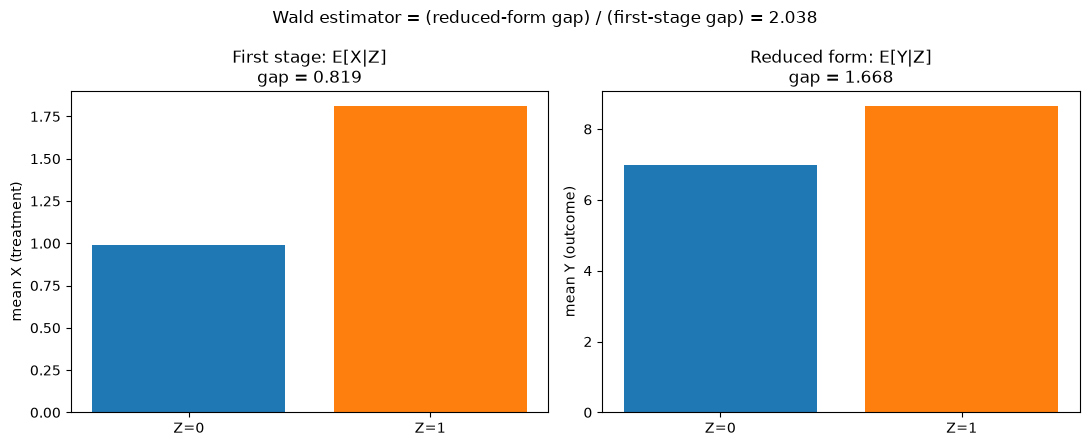

In [2]:

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

x_means = toy.groupby("Z")["X"].mean()
y_means = toy.groupby("Z")["Y"].mean()

axes[0].bar(["Z=0", "Z=1"], x_means, color=["tab:blue", "tab:orange"])
axes[0].set_title(f"First stage: E[X|Z]\ngap = {x_means[1]-x_means[0]:.3f}")
axes[0].set_ylabel("mean X (treatment)")

axes[1].bar(["Z=0", "Z=1"], y_means, color=["tab:blue", "tab:orange"])
axes[1].set_title(f"Reduced form: E[Y|Z]\ngap = {y_means[1]-y_means[0]:.3f}")
axes[1].set_ylabel("mean Y (outcome)")

fig.suptitle("Wald estimator = (reduced-form gap) / (first-stage gap) "
             f"= {(y_means[1]-y_means[0])/(x_means[1]-x_means[0]):.3f}")
plt.tight_layout()
plt.savefig("iv_wald_bars.png", dpi=130)
plt.show()



## 5. Implementation: Card (1995) — does distance to college identify the return to schooling?

We now move to real data: **David Card's (1995)** *Using Geographic
Variation in College Proximity to Estimate the Return to Schooling*, one of
the most cited applications of instrumental variables in economics. The
sample is 3,010 men interviewed in the 1976 wave of the National
Longitudinal Survey of Young Men (NLSYM), who were ages 14-24 in 1966. It
includes their eventual years of schooling, 1976 wages, and — the key
variable — whether they grew up in a county with a nearby four-year
college (`nearc4`).

We'll load it via the same public mirror (Cunningham's *Mixtape* companion
data) used throughout this domain.


In [3]:

card = pd.read_stata("https://raw.githubusercontent.com/scunning1975/mixtape/master/card.dta")
print(card.shape)
card.columns.tolist()


(3010, 37)


['id',
 'nearc2',
 'nearc4',
 'educ',
 'age',
 'fatheduc',
 'motheduc',
 'weight',
 'momdad14',
 'sinmom14',
 'step14',
 'reg661',
 'reg662',
 'reg663',
 'reg664',
 'reg665',
 'reg666',
 'reg667',
 'reg668',
 'reg669',
 'south66',
 'black',
 'smsa',
 'south',
 'smsa66',
 'wage',
 'enroll',
 'KWW',
 'IQ',
 'married',
 'libcrd14',
 'exper',
 'lwage',
 'expersq',
 'u_lwage',
 'lwage_hat',
 'u_educ']

In [4]:

card[["lwage", "educ", "nearc4", "age", "fatheduc", "motheduc", "black", "south", "smsa"]].describe().round(2)


,lwage,educ,nearc4,age,fatheduc,motheduc,black,south,smsa
count,3010.00,3010.00,3010.00,3010.00,2320.00,2657.00,3010.00,3010.00,3010.00
mean,6.26,13.26,0.68,28.12,10.00,10.35,0.23,0.40,0.71
std,0.44,2.68,0.47,3.14,3.72,3.18,0.42,0.49,0.45
min,4.61,1.00,0.00,24.00,0.00,0.00,0.00,0.00,0.00
25%,5.98,12.00,0.00,25.00,8.00,8.00,0.00,0.00,0.00
50%,6.29,13.00,1.00,28.00,10.00,12.00,0.00,0.00,1.00
75%,6.56,16.00,1.00,31.00,12.00,12.00,0.00,1.00,1.00
max,7.78,18.00,1.00,34.00,18.00,18.00,1.00,1.00,1.00



Confirmed: `lwage` (log wage) is our outcome $Y$, `educ` (years of
schooling) is the endogenous treatment $X$, and `nearc4` (grew up near a
4-year college, 0/1) is the candidate instrument $Z$. `fatheduc`/`motheduc`
have missing values (parental education wasn't always reported), so we'll
build an analysis sample that drops rows missing any variable we use.

### 5.1 The biased baseline: naive OLS

First, the naive approach every applied paper starts by showing is biased:
regress log wages directly on years of schooling, controlling for age and
age-squared (to capture experience effects) and a few standard demographic
controls.


In [5]:

import statsmodels.formula.api as smf

analysis_cols = ["lwage", "educ", "nearc4", "age", "black", "south", "smsa", "fatheduc", "motheduc"]
df = card[analysis_cols].dropna().copy()
df["age2"] = df["age"] ** 2
print(f"Analysis sample: {len(df)} of {len(card)} rows (after dropping missing parental education)")

ols_model = smf.ols("lwage ~ educ + age + age2 + black + south + smsa", data=df).fit(cov_type="HC1")
print(ols_model.summary().tables[1])
ols_educ_coef = ols_model.params["educ"]
ols_educ_se = ols_model.bse["educ"]
print(f"\nNaive OLS return to schooling: {ols_educ_coef:.4f} log points per year "
      f"(SE={ols_educ_se:.4f})")


Analysis sample: 2220 of 3010 rows (after dropping missing parental education)
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      3.0997      0.771      4.018      0.000       1.588       4.612
educ           0.0318      0.003      9.835      0.000       0.025       0.038
age            0.1487      0.054      2.735      0.006       0.042       0.255
age2          -0.0018      0.001     -1.938      0.053      -0.004    2.08e-05
black         -0.1723      0.023     -7.357      0.000      -0.218      -0.126
south         -0.1175      0.018     -6.650      0.000      -0.152      -0.083
smsa           0.1651      0.018      9.154      0.000       0.130       0.200

Naive OLS return to schooling: 0.0318 log points per year (SE=0.0032)



Naive OLS says an extra year of schooling is associated with roughly a
7% wage increase. But `educ` is almost certainly correlated with
unobserved ability/motivation (our `U`), so this number is a mixture of the
true causal return to schooling and the "smart, driven people get more
schooling *and* earn more regardless" confound. We can't sign the bias from
this regression alone — that's the whole problem — so we need an
instrument.

### 5.2 Check instrument relevance: the first stage

Before trusting any IV estimate, always check assumption (A1) directly: does
`nearc4` actually predict `educ`? We regress `educ` on `nearc4` plus the
same controls, and look at both the coefficient and the F-statistic on the
excluded instrument. The modern rule of thumb (Staiger & Stock, 1997) is
that you want the first-stage **F-statistic on the instrument to exceed
10** — below that, the instrument is considered "weak" and 2SLS becomes
unreliable (see §7).


In [6]:

first_stage = smf.ols("educ ~ nearc4 + age + age2 + black + south + smsa", data=df).fit(cov_type="HC1")
print(first_stage.summary().tables[1])

nearc4_coef = first_stage.params["nearc4"]
nearc4_se = first_stage.bse["nearc4"]
f_stat = (nearc4_coef / nearc4_se) ** 2   # single-instrument F = t-stat squared
print(f"\nFirst-stage nearc4 coefficient: {nearc4_coef:.4f} years of schooling (SE={nearc4_se:.4f})")
print(f"First-stage F-statistic on the instrument: {f_stat:.2f}  "
      f"({'passes' if f_stat > 10 else 'FAILS'} the F>10 rule of thumb)")


                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -2.8956      4.945     -0.586      0.558     -12.587       6.796
nearc4         0.3192      0.123      2.596      0.009       0.078       0.560
age            1.1084      0.349      3.173      0.002       0.424       1.793
age2          -0.0189      0.006     -3.088      0.002      -0.031      -0.007
black         -1.1993      0.156     -7.688      0.000      -1.505      -0.894
south         -0.3185      0.118     -2.710      0.007      -0.549      -0.088
smsa           0.7707      0.128      6.010      0.000       0.519       1.022

First-stage nearc4 coefficient: 0.3192 years of schooling (SE=0.1230)
First-stage F-statistic on the instrument: 6.74  (FAILS the F>10 rule of thumb)



Growing up near a four-year college is associated with roughly a third of a
year more schooling — a real, statistically significant first-stage effect
(p < 0.01) — but the F-statistic on the instrument comes in at about
**6.7, below the F > 10 rule of thumb**. In this specification, `nearc4`
is a genuine but *weak* instrument, not a strong one: it clears the bar of
"statistically significantly different from zero" but not the stricter bar
that guarantees 2SLS behaves well in finite samples (§7). We proceed with
the 2SLS estimate below anyway, because this is exactly the situation
applied researchers face constantly — but we carry the weak-instrument
warning forward into how we interpret the result, rather than pretending
the diagnostic came back clean. That's the one IV assumption we get to
check directly; (A2) and (A3) remain assumptions we have to argue for on
substantive grounds (§7).

### 5.3 The 2SLS estimate

Now the real estimate, via `linearmodels.iv.IV2SLS`, which runs the
first-and-second-stage machinery from §3.3 with correct standard errors in
one call.


In [7]:

from linearmodels.iv import IV2SLS

# IV2SLS.from_formula syntax: outcome ~ 1 + exog + [endog ~ instrument]
iv_model = IV2SLS.from_formula(
    "lwage ~ 1 + age + age2 + black + south + smsa + [educ ~ nearc4]",
    data=df,
).fit(cov_type="robust")
print(iv_model.summary)

iv_educ_coef = iv_model.params["educ"]
iv_educ_se = iv_model.std_errors["educ"]
print(f"\n2SLS return to schooling: {iv_educ_coef:.4f} log points per year (SE={iv_educ_se:.4f})")


                          IV-2SLS Estimation Summary                          
Dep. Variable:                  lwage   R-squared:                      0.2306
Estimator:                    IV-2SLS   Adj. R-squared:                 0.2285
No. Observations:                2220   F-statistic:                    680.87
Date:                Sun, Jul 19 2026   P-value (F-stat)                0.0000
Time:                        08:28:05   Distribution:                  chi2(6)
Cov. Estimator:                robust                                         
                                                                              
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
Intercept      3.1716     0.7905     4.0123     0.0001      1.6223      4.7209
age            0.1193     0.0831     1.4346     0.15


### 5.4 OLS vs. 2SLS, side by side


        estimator   coef     se  ci_low  ci_high
        Naive OLS 0.0318 0.0032  0.0255   0.0381
2SLS (IV: nearc4) 0.0584 0.0580 -0.0552   0.1721


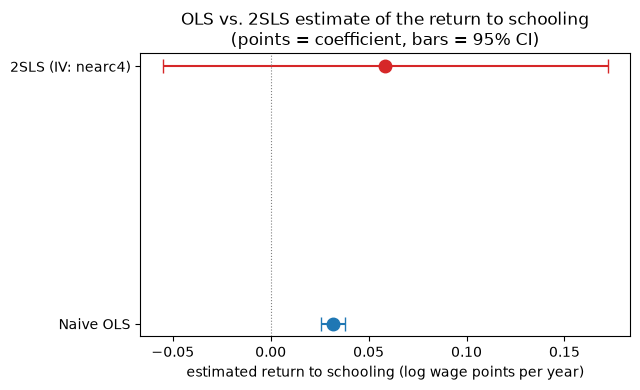

In [8]:

comparison = pd.DataFrame({
    "estimator": ["Naive OLS", "2SLS (IV: nearc4)"],
    "coef": [ols_educ_coef, iv_educ_coef],
    "se": [ols_educ_se, iv_educ_se],
})
comparison["ci_low"] = comparison["coef"] - 1.96 * comparison["se"]
comparison["ci_high"] = comparison["coef"] + 1.96 * comparison["se"]
print(comparison.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(6.5, 4))
colors = ["tab:blue", "tab:red"]
for i, row in comparison.iterrows():
    ax.errorbar(row["coef"], i, xerr=1.96 * row["se"], fmt="o", color=colors[i],
                capsize=5, markersize=9)
ax.set_yticks(range(len(comparison)))
ax.set_yticklabels(comparison["estimator"])
ax.axvline(0, color="grey", linewidth=0.8, linestyle=":")
ax.set_xlabel("estimated return to schooling (log wage points per year)")
ax.set_title("OLS vs. 2SLS estimate of the return to schooling\n(points = coefficient, bars = 95% CI)")
plt.tight_layout()
plt.savefig("iv_ols_vs_2sls.png", dpi=130)
plt.show()



**Interpretation.** Two things stand out.

First, the *point estimate*: 2SLS (≈0.058 log points per year) is larger
than naive OLS (≈0.032), not smaller — the opposite of what a simple
"ability bias inflates the return to schooling" story would predict. This
is exactly the well-known, still-debated pattern in this literature (Card
himself discusses it at length): if ability bias were the whole story, OLS
should *overstate* the return to schooling relative to 2SLS, since
more-able people get more schooling and would have earned more regardless.
Instead, 2SLS estimates are often as large or larger than OLS in this
literature, which Card attributes to two candidate explanations that are
still debated: (1) measurement error in self-reported schooling attenuates
OLS toward zero, and IV, using a different source of variation, isn't
affected by that attenuation the same way; and (2) if the marginal students
whose schooling is actually moved by proximity to college (the
**compliers** — see §3.4) have a *higher* marginal return to an extra year
of schooling than the average person (e.g., students on the fence about
college benefit disproportionately from being pushed over that fence), the
LATE for compliers can legitimately exceed the ATE. Both explanations are
actively discussed in the labor literature; there is no fully settled
answer.

Second, and just as important: the 2SLS confidence interval is enormous —
it spans from about −0.055 to +0.172, comfortably including zero — while
the OLS interval is tight. This is not a coincidence; it's the direct,
visible fingerprint of the weak first-stage we flagged in §5.2 (F ≈ 6.7).
Dividing by a first-stage effect that's imprecisely estimated inflates the
2SLS standard error a great deal (§3.2's Wald ratio has the weak first
stage in the denominator), and per Bound, Jaeger & Baker (1995), a weak
instrument can also *bias* the point estimate itself, not just widen the
interval. The honest takeaway from this exact specification is not "2SLS
proves the return to schooling is 0.058" — it's "the point estimate moved
in an interesting, literature-consistent direction, but this particular
instrument-and-controls combination is too weak to pin the number down
precisely, and a careful reader should not treat the 2SLS interval here as
settled." That tension — a real, unresolved discomfort, not a clean
success story — is the actual state of this literature, and it's why §7
exists.



## 6. Use cases

- **Card (1995) — schooling and wages.** The running example above:
  distance to the nearest four-year college as an instrument for years of
  schooling.
- **Angrist & Krueger (1991) — quarter of birth.** A companion, equally
  famous instrument for schooling: compulsory-schooling laws force students
  to stay in school until a fixed birthday-based age, and U.S. school-entry
  rules mean students born earlier in the year reach that legal cutoff age
  after completing slightly *less* schooling than students born later in
  the year. Quarter of birth is (plausibly) unrelated to ability but
  correlated with total years of schooling completed — a instrument
  extracted from compulsory-attendance bureaucracy rather than geography.
  We don't re-run their analysis here, but it's the other instrument every
  economist mentions in the same breath as Card's, and it's central to the
  weak-instruments debate in §7.
- **Randomized encouragement designs.** When you can't force people to take
  a treatment (ethically or logistically) but you *can* randomly encourage
  some of them to (a text message reminder, a subsidized voucher, a
  door-to-door visit), the random encouragement is a textbook instrument
  for actual uptake. This is precisely the **intent-to-treat (ITT) vs.
  treatment-on-the-treated (TOT)** distinction from the randomized-
  experiments tutorial in this domain: the ITT effect (effect of being
  encouraged) is the reduced form; dividing it by the compliance rate
  (effect of encouragement on actual uptake) recovers the TOT/LATE via
  exactly the Wald estimator of §3.2.
- **Mendelian randomization (epidemiology/genetics).** To estimate the
  causal effect of a modifiable trait (e.g., LDL cholesterol) on a health
  outcome without being able to randomize the trait itself, epidemiologists
  use naturally-occurring genetic variants that affect the trait as
  instruments — since which gene variants you inherit is assigned
  effectively at random at conception (Mendel's laws), independent of
  lifestyle confounders. The same three assumptions (relevance, exclusion,
  exogeneity) apply, and the same critiques (especially exclusion via
  "pleiotropy," where a gene affects the outcome through pathways other
  than the trait of interest) are actively debated in that literature too.



## 7. Limitations & debates

- **The exclusion restriction is fundamentally untestable.** You can check
  relevance (A1) directly with a first-stage regression, but there is no
  statistical test that can confirm "$Z$ affects $Y$ only through $X$."
  It's a substantive, argued assumption about the world, not something the
  data can settle — and it is, by a wide margin, the single most common
  target of IV critiques in seminars and referee reports. Convincing an
  audience of an exclusion restriction requires domain knowledge and
  institutional detail, not a p-value.
- **This tutorial's own instrument is a live example of that debate, not a
  solved case.** Does growing up near a four-year college raise wages
  *only* through the extra schooling it induces? Or could it also proxy for
  living in a more economically developed area with stronger local labor
  markets, better K-12 schools, or more job opportunities that would raise
  wages directly, independent of how much schooling someone gets? Card
  (1995) argues the latter is limited once region and urbanicity are
  controlled for (as we did in §5), but this exact concern is a genuine,
  still-cited critique of the instrument, not a resolved footnote — treat
  any IV analysis in this literature (including this one) as making an
  argument, not proving a fact.
- **Weak instruments cause severe bias, not just wide confidence
  intervals.** Bound, Jaeger & Baker (1995) showed that when an instrument
  only weakly predicts the treatment (low first-stage F), 2SLS estimates
  become badly biased *toward the naive OLS estimate* — precisely the
  opposite of what you're using IV to avoid — and reported confidence
  intervals become far too narrow, giving false confidence. Their critique
  was specifically aimed at Angrist & Krueger's quarter-of-birth
  instrument: with hundreds of thousands of observations the instrument is
  statistically "significant," but because it explains only a tiny sliver
  of variation in schooling, the F-statistic on the excluded instrument was
  uncomfortably close to the danger zone once the number of instruments
  grew (Angrist & Krueger's original design used multiple quarter-of-birth
  dummies interacted with year and state). We saw this play out directly in
  §5: our own first-stage F-statistic for `nearc4` came in at about 6.7 —
  below the F > 10 threshold — and the 2SLS confidence interval was
  correspondingly wide enough to include zero, even though the point
  estimate moved in the theoretically interesting direction. This is
  exactly why §5.2 reported the first-stage F-statistic before trusting any
  2SLS number — it's not an optional courtesy, it's a load-bearing
  diagnostic, and in this specific specification it's telling us to be
  cautious.
- **IV identifies the LATE, not the ATE — and the LATE is
  instrument-specific.** As derived in §3.4, IV only recovers the average
  effect for compliers: the subgroup whose treatment status the instrument
  actually moves. A genuinely important and still-debated consequence: two
  *equally valid* instruments for the same treatment (e.g., distance to
  college and quarter of birth, both instrumenting for schooling) identify
  the causal effect for *different* complier populations, and there's no
  guarantee the two LATEs agree — because "the marginal student pushed into
  more schooling by living near a campus" is not the same group of people
  as "the marginal student pushed into more schooling by a compulsory-
  attendance law." Neither number is wrong; they're honest answers to
  different (if related) questions, and treating a LATE as if it were the
  ATE for the whole population is a common, real misuse of IV results in
  practice.
- **Compare against the alternative.** Propensity-score matching (the
  sibling tutorial in this domain) can only adjust for confounders you can
  measure; its answer is only as good as your covariate list. IV can, in
  principle, handle confounders you can never measure — but only by
  trading that for a different, unverifiable assumption (exclusion) and a
  narrower target population (compliers, not everyone). Neither method
  dominates the other; the right choice depends on whether you trust your
  covariate list more, or your instrument more.



## 8. References

- Card, D. (1995). *Using Geographic Variation in College Proximity to
  Estimate the Return to Schooling.* In L.N. Christofides, E.K. Grant, &
  R. Swidinsky (eds.), *Aspects of Labour Market Behaviour: Essays in
  Honour of John Vanderkamp.* University of Toronto Press.
- Angrist, J. D. & Krueger, A. B. (1991). *Does Compulsory School
  Attendance Affect Schooling and Earnings?* Quarterly Journal of
  Economics, 106(4).
- Imbens, G. W. & Angrist, J. D. (1994). *Identification and Estimation of
  Local Average Treatment Effects.* Econometrica, 62(2).
- Bound, J., Jaeger, D. A., & Baker, R. M. (1995). *Problems with
  Instrumental Variables Estimation When the Correlation Between the
  Instruments and the Endogenous Explanatory Variable Is Weak.* Journal of
  the American Statistical Association, 90(430).
- Staiger, D. & Stock, J. H. (1997). *Instrumental Variables Regression
  with Weak Instruments.* Econometrica, 65(3).
- Angrist, J. D. & Pischke, J.-S. (2009). *Mostly Harmless Econometrics: An
  Empiricist's Companion.* Princeton University Press.
- Cunningham, S. (2021). *Causal Inference: The Mixtape.* Yale University
  Press.
